# AFL Fantasy × Deep Neural Networks — a learning notebook

This notebook builds, step by step, the project we developed together: using AFL Fantasy
data to *learn* how deep neural networks work in Keras/TensorFlow.

**The arc**

1. **The data** — 5 seasons of per-player, per-match stats (scraped from FootyWire).
2. **Fundamentals** — predict next-round fantasy score; naive baselines → linear regression → a neural net. The key lessons: *data leakage*, *temporal splits*, and *why model complexity has to earn its keep*.
3. **Deliverable #1 — Autoencoder:** compress each player into a 2D latent vector and discover *archetypes* (ruck, inside mid, key forward, ...).
4. **Deliverable #2 — LSTM:** read a player's game-by-game *trajectory* to detect form swings and anomalies.

> Prerequisite: the dataset `data/processed/player_match_stats.csv` already exists (produced by `src/scrape_footywire.py`). This notebook just consumes it, so it runs in a minute or two.

**The big takeaway, up front:** neural nets won't beat a simple baseline at plain prediction here — but they shine at *representation* (archetypes) and *sequence* (form). That contrast is the whole point.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from tensorflow import keras

warnings.filterwarnings("ignore")
keras.utils.set_random_seed(42)  # reproducible runs

# Resolve the project root whether we launch from repo root or the notebooks/ folder.
ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent
DATA = ROOT / "data" / "processed" / "player_match_stats.csv"

print("TensorFlow", keras.backend.backend(), "| Keras", keras.__version__)
print("dataset:", DATA.exists(), "->", DATA)

TensorFlow tensorflow | Keras 3.14.1
dataset: True -> C:\Users\Delophant\.cursor\AFLFantasy-DNN\data\processed\player_match_stats.csv


## 1. The data

One row per **player per match**: the raw stat categories (kicks, marks, tackles, hitouts, ...)
plus the **AFL Fantasy (AF)** score, which is what we'll predict and analyze.

First, sanity checks — does the data make football sense?

In [2]:
df = pd.read_csv(DATA, parse_dates=["date"])

print(f"rows (player-matches): {len(df):,}")
print(f"matches: {df['match_id'].nunique():,} | players: {df['player'].nunique():,} | teams: {df['team'].nunique()}")
print(f"seasons: {sorted(df['season'].unique())}")
print(f"missing values: {int(df.isna().sum().sum())}")

# Does it pass the smell test? Top fantasy scorers should be the known premiums.
games = df.groupby("player").size()
elig = games[games >= 20].index
top = (df[df["player"].isin(elig)].groupby("player")["fantasy_points"]
       .mean().sort_values(ascending=False).head(10).round(1))
print("\nTop 10 by average fantasy (min 20 games):")
print(top.to_string())

rows (player-matches): 48,270
matches: 1,058 | players: 1,027 | teams: 18
seasons: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
missing values: 0

Top 10 by average fantasy (min 20 games):
player
Marcus Bontempelli    108.3
Zachary Merrett       108.0
Max Gawn              107.0
Andrew Brayshaw       106.9
Jack Steele           106.6
Rory Laird            106.4
Harry Sheezel         106.0
Rowan Marshall        105.9
Josh Dunkley          104.4
Jordan Dawson         103.5


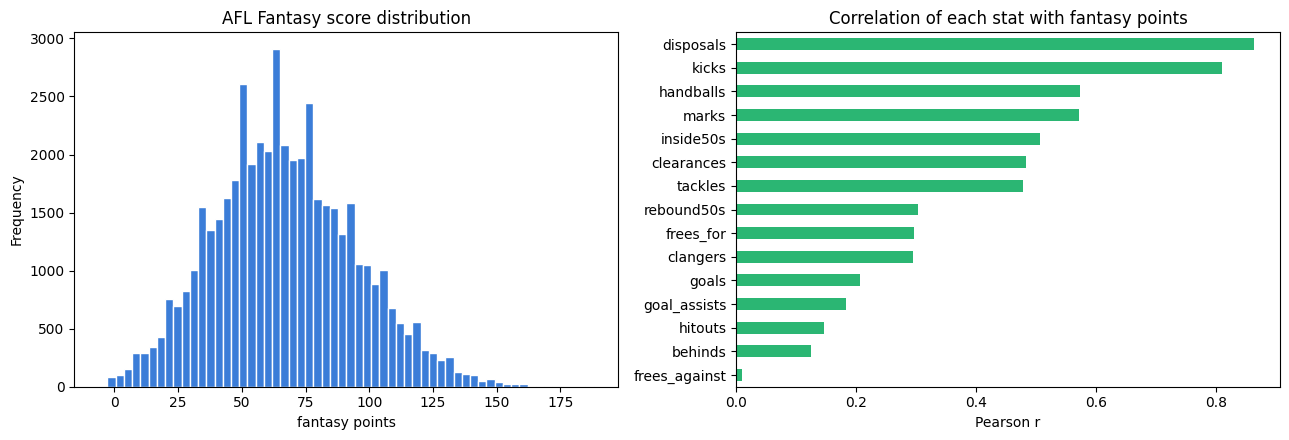

mean     66.9
std      27.8
min      -6.0
max     188.0


In [3]:
STAT_COLS = ["kicks", "handballs", "disposals", "marks", "goals", "behinds", "tackles",
             "hitouts", "goal_assists", "inside50s", "clearances", "clangers",
             "rebound50s", "frees_for", "frees_against"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) The target's distribution: roughly bell-shaped, mean ~67, can go negative.
df["fantasy_points"].plot.hist(bins=60, ax=axes[0], color="#3b7dd8", edgecolor="white")
axes[0].set_title("AFL Fantasy score distribution")
axes[0].set_xlabel("fantasy points")

# (b) Which raw stats drive fantasy points? Disposals & kicks dominate.
corr = df[STAT_COLS + ["fantasy_points"]].corr()["fantasy_points"].drop("fantasy_points").sort_values()
corr.plot.barh(ax=axes[1], color="#2bb673")
axes[1].set_title("Correlation of each stat with fantasy points")
axes[1].set_xlabel("Pearson r")

plt.tight_layout(); plt.show()
print(df["fantasy_points"].describe()[["mean", "std", "min", "max"]].round(1).to_string())

## 2. Fundamentals — predicting next-round fantasy score

### The leakage trap ⚠️
A player's disposals *in a game* trivially predict *that same game's* fantasy score (r = 0.86) — because the score is computed **from** those stats. Using same-game stats would look brilliant and be useless: on Thursday you don't know Saturday's disposals.

So the only honest features come from a player's **prior** games (recent form, season/career averages). We predict the **current** game from the **past**. This also forces a **temporal split**: train on earlier seasons, test on a later one — never shuffle randomly, or you "remember the future".

We build that leakage-free feature table below (`.shift(1)` = "previous game").

In [4]:
d = df.sort_values(["player", "date"]).reset_index(drop=True)
g = d.groupby("player", sort=False)

def prior_roll(col, w):  # rolling mean of PAST games only (shifted)
    return g[col].transform(lambda s: s.shift(1).rolling(w, min_periods=w).mean())

d["prev_score"]         = g["fantasy_points"].shift(1)
d["roll3_fantasy"]      = prior_roll("fantasy_points", 3)
d["roll5_fantasy"]      = prior_roll("fantasy_points", 5)
d["roll3_disposals"]    = prior_roll("disposals", 3)
d["roll5_disposals"]    = prior_roll("disposals", 5)
d["roll3_tackles"]      = prior_roll("tackles", 3)
d["career_avg_fantasy"] = g["fantasy_points"].transform(lambda s: s.shift(1).expanding(min_periods=1).mean())
d["season_avg_fantasy"] = d.groupby(["player", "season"])["fantasy_points"].transform(lambda s: s.shift(1).expanding(min_periods=1).mean())
d["games_played"]       = g.cumcount()
d["is_home"]            = (d["home_away"] == "home").astype(int)
d["target"]             = d["fantasy_points"]

FEATURES = ["prev_score", "roll3_fantasy", "roll5_fantasy", "season_avg_fantasy",
            "career_avg_fantasy", "roll3_disposals", "roll5_disposals",
            "roll3_tackles", "games_played", "is_home"]

reg = d.dropna(subset=FEATURES).reset_index(drop=True)  # drop warm-up games (<3 prior)
print(f"modelling rows: {len(reg):,}  (features: {len(FEATURES)})")
reg[["season", "player"] + FEATURES + ["target"]].head()

modelling rows: 41,300  (features: 10)


,season,player,prev_score,roll3_fantasy,roll5_fantasy,season_avg_fantasy,career_avg_fantasy,roll3_disposals,roll5_disposals,roll3_tackles,games_played,is_home,target
0,2023,Aaron Cadman,24.0,24.000000,27.2,27.200000,27.200000,4.666667,5.0,1.333333,5,1,37.0
1,2023,Aaron Cadman,37.0,25.666667,28.8,28.833333,28.833333,5.000000,4.8,1.333333,6,0,21.0
2,2023,Aaron Cadman,21.0,27.333333,26.0,27.714286,27.714286,5.333333,4.6,1.333333,7,1,26.0
3,2023,Aaron Cadman,26.0,28.000000,24.8,27.500000,27.500000,3.666667,4.2,1.666667,8,1,7.0
4,2023,Aaron Cadman,7.0,18.000000,23.0,25.222222,25.222222,3.000000,4.2,1.333333,9,0,36.0


### The model ladder + naive baselines

We compare, on the **same held-out 2025 test season**:

- **Naive baselines** (no learning): global mean, last score, running averages. These are the *bar to beat*.
- **Linear regression** (scikit-learn, exact closed-form solve).
- **Linear model in Keras** — `Dense(1)` with no hidden layer / no activation. This *is* linear regression, just solved by gradient descent (it should match sklearn).
- **Neural net** — hidden layers + ReLU.

> Note the learning rates: with standardized inputs the network's output starts near 0 but the target averages ~67, so the bias has to *travel*. Adam moves ~`lr` per step, so too-small an `lr` stalls before arriving. We bump it so the Keras linear model actually converges to sklearn's answer.

In [5]:
train = reg[reg["season"].isin([2021, 2022, 2023])]
val   = reg[reg["season"] == 2024]
test  = reg[reg["season"] == 2025]
print(f"train {len(train):,} | val {len(val):,} | test {len(test):,}")

Xtr_raw, ytr = train[FEATURES].to_numpy(), train["target"].to_numpy()
Xva_raw, yva = val[FEATURES].to_numpy(),   val["target"].to_numpy()
Xte_raw, yte = test[FEATURES].to_numpy(),  test["target"].to_numpy()

scaler = StandardScaler().fit(Xtr_raw)   # fit on TRAIN only (no test leakage)
Xtr, Xva, Xte = scaler.transform(Xtr_raw), scaler.transform(Xva_raw), scaler.transform(Xte_raw)

def score(name, y_pred, store):
    store[name] = (mean_absolute_error(yte, y_pred), float(np.sqrt(mean_squared_error(yte, y_pred))))

results = {}
score("Naive: global mean", np.full_like(yte, ytr.mean(), dtype=float), results)
score("Naive: last score",  test["prev_score"].to_numpy(), results)
score("Naive: season avg",  test["season_avg_fantasy"].to_numpy(), results)
score("Naive: career avg",  test["career_avg_fantasy"].to_numpy(), results)

lin = LinearRegression().fit(Xtr, ytr)
score("Linear regression (sklearn)", lin.predict(Xte), results)

def keras_linear(n):
    m = keras.Sequential([keras.layers.Input((n,)), keras.layers.Dense(1)])
    m.compile(keras.optimizers.Adam(0.05), "mse", metrics=["mae"]); return m

def keras_mlp(n):
    m = keras.Sequential([keras.layers.Input((n,)),
                          keras.layers.Dense(32, activation="relu"),
                          keras.layers.Dense(16, activation="relu"),
                          keras.layers.Dense(1)])
    m.compile(keras.optimizers.Adam(0.01), "mse", metrics=["mae"]); return m

es = keras.callbacks.EarlyStopping("val_loss", patience=12, restore_best_weights=True)

klin = keras_linear(Xtr.shape[1])
klin.fit(Xtr, ytr, validation_data=(Xva, yva), epochs=200, batch_size=256, verbose=0, callbacks=[es])
score("Linear (Keras Dense(1))", klin.predict(Xte, verbose=0).ravel(), results)

mlp = keras_mlp(Xtr.shape[1])
hist = mlp.fit(Xtr, ytr, validation_data=(Xva, yva), epochs=200, batch_size=256, verbose=0, callbacks=[es])
mlp_pred = mlp.predict(Xte, verbose=0).ravel()
score("Neural net (32-16, ReLU)", mlp_pred, results)

print(f"\n{'model':<32}{'MAE':>8}{'RMSE':>9}")
print("-" * 49)
for name, (mae, rmse) in sorted(results.items(), key=lambda kv: kv[1][0]):
    print(f"{name:<32}{mae:>8.2f}{rmse:>9.2f}")

train 23,360 | val 9,000 | test 8,940



model                                MAE     RMSE
-------------------------------------------------
Linear (Keras Dense(1))            17.42    21.98
Linear regression (sklearn)        17.43    21.97
Neural net (32-16, ReLU)           17.66    22.24
Naive: career avg                  18.12    22.92
Naive: season avg                  18.15    22.92
Naive: global mean                 22.47    27.93
Naive: last score                  22.63    28.66


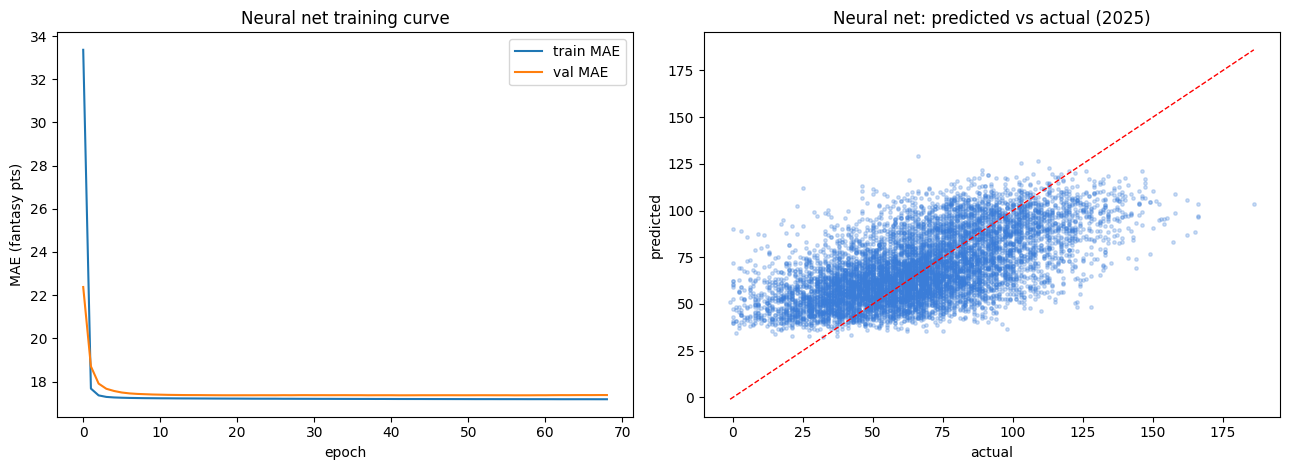

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# Training curve: train ~ val, plateau -> no overfitting, just hit the data's ceiling.
axes[0].plot(hist.history["mae"], label="train MAE")
axes[0].plot(hist.history["val_mae"], label="val MAE")
axes[0].set_title("Neural net training curve"); axes[0].set_xlabel("epoch")
axes[0].set_ylabel("MAE (fantasy pts)"); axes[0].legend()

# Predicted vs actual: the cloud is squashed to the middle = regression to the mean.
axes[1].scatter(yte, mlp_pred, s=6, alpha=0.25, color="#3b7dd8")
lims = [yte.min(), yte.max()]
axes[1].plot(lims, lims, "r--", lw=1)
axes[1].set_title("Neural net: predicted vs actual (2025)")
axes[1].set_xlabel("actual"); axes[1].set_ylabel("predicted")

plt.tight_layout(); plt.show()

**Read the table:** the neural net does **not** beat plain linear regression, and both only just edge out "predict their season average". Our features are aggregates of past form, so every model converges on "predict their average, nudged a little". The single-game variance is largely *irreducible* from form alone.

That's the motivation for the next two sections — tasks where neural nets genuinely add value.

---
## 3. Deliverable #1 — Autoencoder for archetype discovery

An **autoencoder** squeezes each input through a narrow **bottleneck** and reconstructs it. To rebuild a player's ~14-stat profile from just **2 numbers**, the network must learn the few axes that truly separate playing styles. We then cluster that 2D space into **archetypes**.

Unit = one **player-season** (their per-game averages). This is *representation learning* — something linear/tree models can't do. (A linear autoencoder would just recover PCA; the ReLU lets it bend the space.)

In [7]:
# Style features (per-game). Omit 'disposals' (= kicks+handballs) and fantasy/supercoach (derived).
STYLE = ["kicks", "handballs", "marks", "goals", "behinds", "tackles", "hitouts",
         "goal_assists", "inside50s", "clearances", "clangers", "rebound50s",
         "frees_for", "frees_against"]

gms = df.groupby(["player", "season"]).size().rename("games")
profiles = df.groupby(["player", "season"])[STYLE].mean().join(gms).reset_index()
profiles = profiles[profiles["games"] >= 8].reset_index(drop=True)   # stable profiles only
print(f"player-season profiles: {len(profiles):,}")

Xp = StandardScaler().fit_transform(profiles[STYLE].to_numpy())

# Autoencoder: 14 -> 8 -> [2] -> 8 -> 14
inp = keras.layers.Input((Xp.shape[1],))
h = keras.layers.Dense(8, activation="relu")(inp)
latent = keras.layers.Dense(2, name="latent")(h)
h = keras.layers.Dense(8, activation="relu")(latent)
out = keras.layers.Dense(Xp.shape[1])(h)
autoenc = keras.Model(inp, out); encoder = keras.Model(inp, latent)
autoenc.compile("adam", "mse")
autoenc.fit(Xp, Xp, validation_split=0.15, epochs=400, batch_size=32, verbose=0,
            callbacks=[keras.callbacks.EarlyStopping("val_loss", patience=25, restore_best_weights=True)])

recon_mse = float(np.mean((Xp - autoenc.predict(Xp, verbose=0)) ** 2))
print(f"reconstruction MSE (standardized): {recon_mse:.3f}   (1.0 = no better than the mean)")

Z = encoder.predict(Xp, verbose=0)
profiles["lat1"], profiles["lat2"] = Z[:, 0], Z[:, 1]
profiles["cluster"] = KMeans(6, random_state=42, n_init=10).fit_predict(Z)

# Name each cluster by its most distinctive per-game stats vs league average.
mu, sd = profiles[STYLE].mean(), profiles[STYLE].std()
labels = {}
for c in sorted(profiles["cluster"].unique()):
    z = ((profiles[profiles.cluster == c][STYLE].mean() - mu) / sd).sort_values(ascending=False)
    labels[c] = ", ".join(f"{s}+" for s in z.head(2).index)
    print(f"cluster {c} (n={int((profiles.cluster==c).sum()):4d}): {labels[c]}")

player-season profiles: 2,502


reconstruction MSE (standardized): 0.262   (1.0 = no better than the mean)


cluster 0 (n= 380): rebound50s+, marks+
cluster 1 (n= 456): rebound50s+, marks+
cluster 2 (n= 139): hitouts+, frees_against+
cluster 3 (n= 922): goals+, behinds+
cluster 4 (n= 191): rebound50s+, marks+
cluster 5 (n= 414): clearances+, handballs+


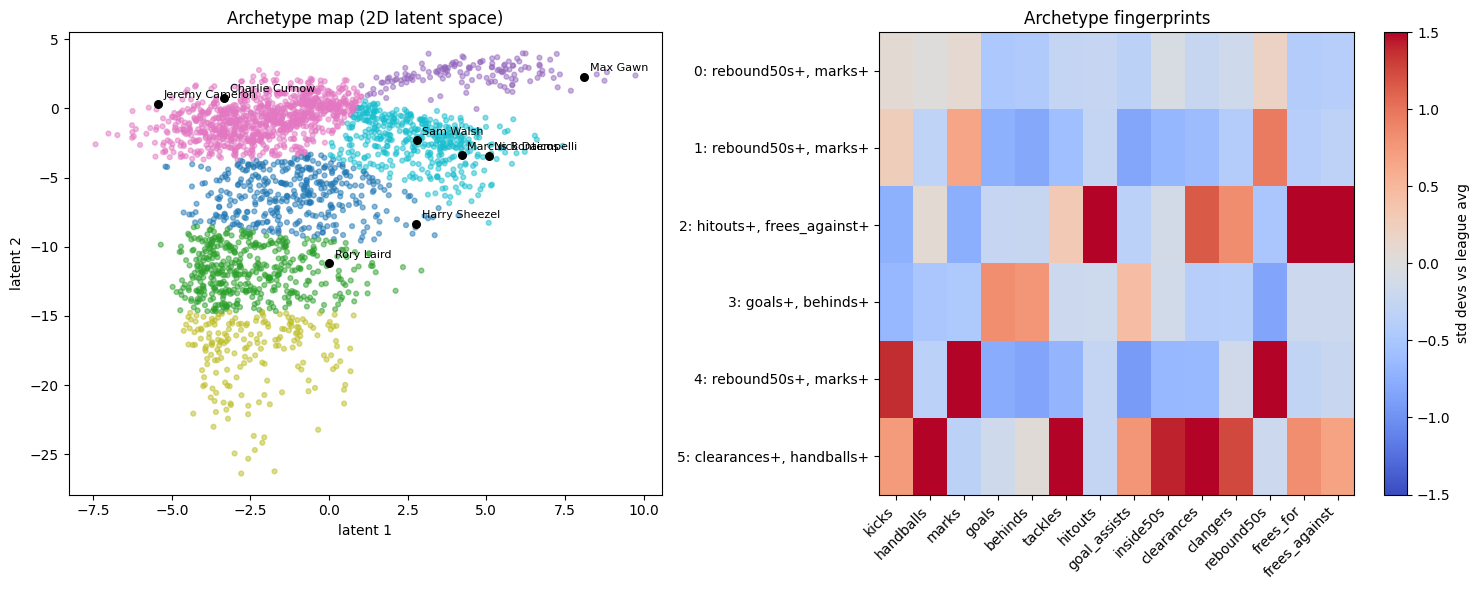

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# (a) The latent archetype map, with recognisable players annotated.
sc = axes[0].scatter(profiles["lat1"], profiles["lat2"], c=profiles["cluster"],
                     cmap="tab10", s=12, alpha=0.5)
latest = profiles.sort_values("season").drop_duplicates("player", keep="last")
for name in ["Max Gawn", "Marcus Bontempelli", "Nick Daicos", "Charlie Curnow",
             "Jeremy Cameron", "Rory Laird", "Sam Walsh", "Harry Sheezel"]:
    r = latest[latest["player"] == name]
    if not r.empty:
        x, y = r["lat1"].iloc[0], r["lat2"].iloc[0]
        axes[0].scatter([x], [y], color="black", s=30, zorder=5)
        axes[0].annotate(name, (x, y), fontsize=8, xytext=(4, 4), textcoords="offset points")
axes[0].set_title("Archetype map (2D latent space)")
axes[0].set_xlabel("latent 1"); axes[0].set_ylabel("latent 2")

# (b) Archetype fingerprints: z-scored centroids per cluster.
cent = profiles.groupby("cluster")[STYLE].mean().sub(mu).div(sd)
im = axes[1].imshow(cent.to_numpy(), cmap="coolwarm", vmin=-1.5, vmax=1.5, aspect="auto")
fig.colorbar(im, ax=axes[1], label="std devs vs league avg")
axes[1].set_yticks(range(6)); axes[1].set_yticklabels([f"{c}: {labels[c]}" for c in range(6)])
axes[1].set_xticks(range(len(STYLE))); axes[1].set_xticklabels(STYLE, rotation=45, ha="right")
axes[1].set_title("Archetype fingerprints")

plt.tight_layout(); plt.show()

The autoencoder rediscovered real positions with no knowledge of them: rucks (Gawn) sit on their own island, inside mids (Bontempelli, Daicos) anchor one end, key forwards (Curnow, Cameron) another, rebounding defenders (Laird) in between — and it's a *continuous spectrum* of roles, not rigid boxes. That's the magic of a learned latent space.

---
## 4. Deliverable #2 — LSTM for form & anomaly detection

Averages threw away the **shape** of recent games. An **LSTM** reads the actual game-by-game sequence, so it can (a) test whether trajectory shape beats the average, and (b) give us a form signal:

- `predicted − recent_average` → **"about to hit form"** (or cool off)
- `actual − predicted` → over/under-performance **anomaly**

We feed the last 5 games (full stat-lines) to predict the next game's score. Sequences are built **within a season** so we never bridge the off-season gap.

In [9]:
SEQ_FEATURES = STYLE + ["fantasy_points"]   # 15 features per timestep
SEQ_LEN = 5

dd = df.sort_values(["player", "season", "date"])
feat = dd[SEQ_FEATURES].to_numpy("float32")
dates_all = dd["date"].to_numpy()

X, y, seas, recent, who, when = [], [], [], [], [], []
for (player, season), idx in dd.groupby(["player", "season"], sort=False).indices.items():
    idx = np.sort(idx)
    fp = feat[idx][:, -1]
    for t in range(SEQ_LEN, len(idx)):
        X.append(feat[idx[t - SEQ_LEN:t]]); y.append(fp[t])
        recent.append(fp[t - SEQ_LEN:t].mean()); seas.append(season)
        who.append(player); when.append(dates_all[idx[t]])

X = np.asarray(X, "float32"); y = np.asarray(y, "float32")
seas = np.asarray(seas); recent = np.asarray(recent, "float32")
who = np.asarray(who); when = np.asarray(when)
print(f"sequences: {len(X):,}  shape {X.shape}")

tr = np.isin(seas, [2021, 2022, 2023]); va = seas == 2024; te = seas == 2025
flat = X[tr].reshape(-1, X.shape[-1])
m, s = flat.mean(0), flat.std(0) + 1e-8
Xn = (X - m) / s

lstm = keras.Sequential([keras.layers.Input((SEQ_LEN, X.shape[-1])),
                         keras.layers.LSTM(32),
                         keras.layers.Dense(16, activation="relu"),
                         keras.layers.Dense(1)])
lstm.compile(keras.optimizers.Adam(1e-3), "mse", metrics=["mae"])
hl = lstm.fit(Xn[tr], y[tr], validation_data=(Xn[va], y[va]), epochs=120, batch_size=128,
              verbose=0, callbacks=[keras.callbacks.EarlyStopping("val_loss", patience=12, restore_best_weights=True)])

pred = lstm.predict(Xn[te], verbose=0).ravel()
lstm_mae = mean_absolute_error(y[te], pred)
base_mae = mean_absolute_error(y[te], recent[te])
print(f"\nNaive last-5 average  MAE: {base_mae:5.2f}")
print(f"LSTM sequence model   MAE: {lstm_mae:5.2f}   <- beats the baseline")

sequences: 32,925  shape (32925, 5, 15)



Naive last-5 average  MAE: 18.12
LSTM sequence model   MAE: 17.67   <- beats the baseline


ABOUT TO HIT FORM (model predicts a jump vs recent avg):
        player       date  recent_avg  predicted  actual
 Lance Collard 2025-08-15   17.799999  37.900002    21.0
Jordan De Goey 2025-09-04   46.400002  66.199997   107.0
 Max Gruzewski 2025-08-24   28.000000  47.500000    68.0
   Dylan Shiel 2025-08-02   58.000000  77.400002    48.0
 Lance Collard 2025-08-24   16.400000  35.599998    37.0
   Ted Clohesy 2025-06-07   15.400000  34.400002    83.0

ABOUT TO COOL OFF (model predicts a drop = mean reversion):
        player       date  recent_avg  predicted  actual
  Bailey Smith 2025-06-20  136.199997 106.599998    94.0
Jeremy Cameron 2025-09-05   99.800003  70.900002    89.0
      Max Gawn 2025-06-01  133.199997 105.900002   107.0
Aaron Naughton 2025-07-31   97.000000  70.300003   113.0
Jeremy Cameron 2025-08-08   94.400002  67.800003   104.0
  Bailey Smith 2025-06-14  132.800003 106.500000   136.0

BIGGEST ANOMALIES (actual blew past prediction):
            player       date  rec

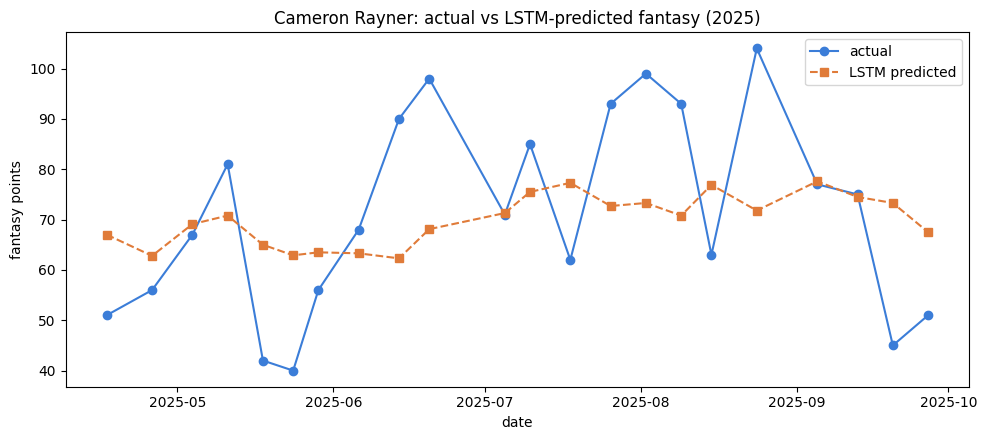

In [10]:
watch = pd.DataFrame({"player": who[te], "date": when[te],
                      "recent_avg": recent[te].round(1), "predicted": pred.round(1),
                      "actual": y[te]})
watch["delta_vs_recent"] = (watch["predicted"] - watch["recent_avg"]).round(1)
watch["surprise"] = (watch["actual"] - watch["predicted"]).round(1)

cols = ["player", "date", "recent_avg", "predicted", "actual"]
print("ABOUT TO HIT FORM (model predicts a jump vs recent avg):")
print(watch.sort_values("delta_vs_recent", ascending=False).head(6)[cols].to_string(index=False))
print("\nABOUT TO COOL OFF (model predicts a drop = mean reversion):")
print(watch.sort_values("delta_vs_recent").head(6)[cols].to_string(index=False))
print("\nBIGGEST ANOMALIES (actual blew past prediction):")
print(watch.sort_values("surprise", ascending=False).head(6)[cols].to_string(index=False))

# One player's 2025 trajectory: the LSTM tracks the form *level* and smooths spikes.
star = watch["player"].value_counts().index[0]
sdf = watch[watch["player"] == star].sort_values("date")
plt.figure(figsize=(10, 4.5))
plt.plot(sdf["date"], sdf["actual"], "o-", label="actual", color="#3b7dd8")
plt.plot(sdf["date"], sdf["predicted"], "s--", label="LSTM predicted", color="#e07b39")
plt.title(f"{star}: actual vs LSTM-predicted fantasy (2025)")
plt.xlabel("date"); plt.ylabel("fantasy points"); plt.legend()
plt.tight_layout(); plt.show()

## Takeaways

| Step | What it taught |
|---|---|
| **Fundamentals** | forward pass, loss, backprop, train/val/test, **leakage**, temporal splits, baselines, the **linear ↔ deep** bridge, and that complexity must *earn its keep* |
| **Autoencoder** | bottlenecks, **latent representations**, clustering — what NNs do that trees can't |
| **LSTM** | **sequence** modeling, mean reversion, signal vs irreducible variance |

The throughline: **neural nets didn't help for plain prediction (tied/lost to a linear baseline), but shone for representation (archetypes) and sequence (form).**

### Where to go next
- **VAE**: a *variational* autoencoder for a smoother, generative archetype space.
- **Beat the baseline for real**: add opponent strength, role, days' rest, venue effects.
- **Sequence-autoencoder anomaly detection**: reconstruct recent form; high error = something changed.
- **Classification**: frame "breakout next week" as a yes/no problem and measure precision/recall.